In [1]:
import os

folder_path = "GpC26"

data = {}

'''
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        data[file] = load_spectrum(file_path)
        '''

'\nfor file in os.listdir(folder_path):\n    if file.endswith(".csv"):\n        file_path = os.path.join(folder_path, file)\n        data[file] = load_spectrum(file_path)\n        '

In [2]:
import pandas as pd

def load_spectrum(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    start_row = None
    for i, line in enumerate(lines):
        if "Channel" in line:
            start_row = i
            break

    df = pd.read_csv(file_path, skiprows=start_row)

    df.columns = df.columns.str.strip().str.replace(",", "")
    df = df.iloc[:, :3]
    df.columns = ["Channel", "Energy", "Counts"]

    df = df[["Channel", "Counts"]]

    df["Channel"] = pd.to_numeric(df["Channel"], errors="coerce")
    df["Counts"] = pd.to_numeric(df["Counts"], errors="coerce")

    df = df.dropna()

    return df

In [3]:
angle_data = {}

angle_data[-6] = load_spectrum("GpC26/-6degrees.csv")
angle_data[-5] = load_spectrum("GpC26/-5degrees.csv")
angle_data[-4] = load_spectrum("GpC26/-4degrees.csv")
angle_data[-3] = load_spectrum("GpC26/-3degrees.csv")
angle_data[-2] = load_spectrum("GpC26/-2degrees.csv")
angle_data[-1] = load_spectrum("GpC26/-1degrees.csv")
angle_data[0] = load_spectrum("GpC26/0degrees.csv")
angle_data[1] = load_spectrum("GpC26/1degree.csv")
angle_data[2] = load_spectrum("GpC26/2degrees.csv")
angle_data[3] = load_spectrum("GpC26/3degrees.csv")
angle_data[4] = load_spectrum("GpC26/4degrees.csv")
angle_data[5] = load_spectrum("GpC26/5degrees.csv")
angle_data[6] = load_spectrum("GpC26/6degrees.csv")

coince_on = load_spectrum("GpC26/20degrees20minutesgateon.csv")
coince_off = load_spectrum("GpC26/counter1_20deg_20min_nogate.csv")
detect2 = load_spectrum("GpC26/counter2_2h.csv")
callibration2 = load_spectrum("GpC26/counter1_5minsnocoincidence.csv")



In [4]:
poisson_68_table = {
    0: (0.0, 1.84),
    1: (0.17, 3.30),
    3: (1.37, 5.92),
    4: (2.09, 7.16),
    16: (12.04, 21.08),
    14: (10.03, 18.83),
}

----- Peak Positions -----
0.511 MeV peak:  channel = 318.83 ± 0.16
1.274 MeV peak: channel = 769.84 ± 0.57

----- Calibration -----
a = 1.654881e-03 ± 1.55e-06 MeV/channel

----- Result -----
E(0.511 peak) = 0.5276 ± 0.0017 MeV
Expected = 0.511 MeV


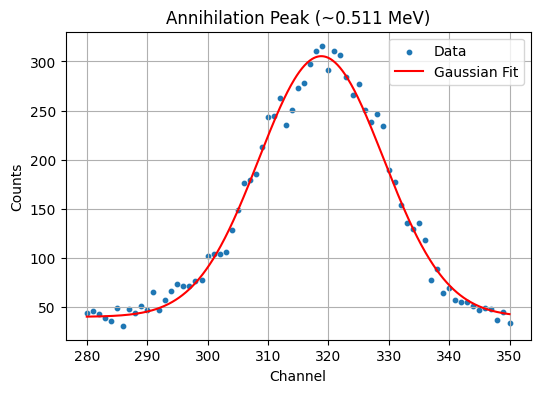

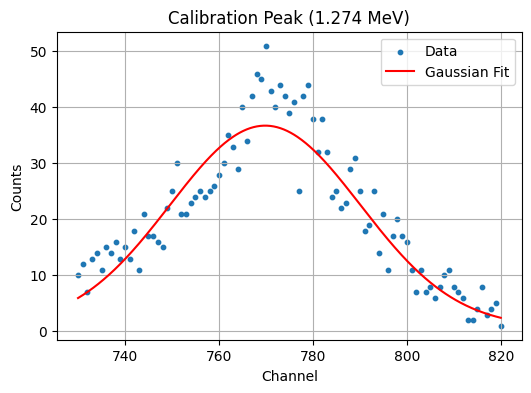

In [5]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

def fit_peak(df, ch_min, ch_max):
    peak_df = df[df["Channel"].between(ch_min, ch_max)]

    x = peak_df["Channel"].values
    y = peak_df["Counts"].values


    sigma_y = np.sqrt(y)
    sigma_y[sigma_y == 0] = 1.0  # avoid divide-by-zero


    A0 = np.max(y)
    mu0 = x[np.argmax(y)]
    sigma0 = (ch_max - ch_min) / 6
    C0 = np.min(y)

    popt, pcov = curve_fit(
        gaussian,
        x, y,
        p0=[A0, mu0, sigma0, C0],
        sigma=sigma_y,
        absolute_sigma=True
    )

    A, mu, sigma, C = popt
    mu_err = np.sqrt(pcov[1, 1])

    return mu, mu_err, popt


df_cal = coince_off 

mu_511, err_511, fit_511 = fit_peak(df_cal, 280, 350)
mu_1274, err_1274, fit_1274 = fit_peak(df_cal, 730, 820)

print("----- Peak Positions -----")
print(f"0.511 MeV peak:  channel = {mu_511:.2f} ± {err_511:.2f}")
print(f"1.274 MeV peak: channel = {mu_1274:.2f} ± {err_1274:.2f}")

def poisson_scale_error(df, ch_min, ch_max):
    peak_counts = df[df["Channel"].between(ch_min, ch_max)]["Counts"].sum()

    if peak_counts < 50:
    
        sigma = np.sqrt(peak_counts)
    else:
        sigma = np.sqrt(peak_counts)

    return sigma


sigma_1274_counts = poisson_scale_error(df_cal, 730, 820)
sigma_511_counts = poisson_scale_error(df_cal, 280, 350)

E_known = 1.274  # MeV

a = E_known / mu_1274


mu1274_total_err = np.sqrt(err_1274**2 + (sigma_1274_counts * 0.01)**2)

a_err = a * (mu1274_total_err / mu_1274)

print("\n----- Calibration -----")
print(f"a = {a:.6e} ± {a_err:.2e} MeV/channel")



E_511 = a * mu_511

mu511_total_err = np.sqrt(err_511**2 + (sigma_511_counts * 0.01)**2)

E_511_err = E_511 * np.sqrt(
    (mu511_total_err / mu_511)**2 +
    (a_err / a)**2
)

print("\n----- Result -----")
print(f"E(0.511 peak) = {E_511:.4f} ± {E_511_err:.4f} MeV")
print("Expected = 0.511 MeV")


def plot_fit(df, ch_min, ch_max, popt, title):
    peak_df = df[df["Channel"].between(ch_min, ch_max)]

    x = peak_df["Channel"].values
    y = peak_df["Counts"].values

    x_fit = np.linspace(ch_min, ch_max, 500)
    y_fit = gaussian(x_fit, *popt)

    plt.figure(figsize=(6,4))
    plt.scatter(x, y, s=10, label="Data")
    plt.plot(x_fit, y_fit, color="red", label="Gaussian Fit")

    plt.xlabel("Channel")
    plt.ylabel("Counts")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()


plot_fit(df_cal, 280, 350, fit_511, "Annihilation Peak (~0.511 MeV)")
plot_fit(df_cal, 730, 820, fit_1274, "Calibration Peak (1.274 MeV)")


In [6]:
def print_bin_counts_with_error(df, ch_min, ch_max, label):
    region = df[df["Channel"].between(ch_min, ch_max)].copy()

    region["σ (Poisson)"] = np.sqrt(region["Counts"])
    region["Rate (counts/s)"] = region["Counts"] / 300
    region["σ Rate"] = region["σ (Poisson)"] / 300

    print(f"\n----- {label}: Bin-by-bin counts with Poisson error -----")
    print(region[["Channel", "Counts", "σ (Poisson)", "Rate (counts/s)", "σ Rate"]].to_string(index=False))
print_bin_counts_with_error(df_cal, 280, 350, "0.511 MeV Peak")
print_bin_counts_with_error(df_cal, 730, 820, "1.274 MeV Peak")


----- 0.511 MeV Peak: Bin-by-bin counts with Poisson error -----
 Channel  Counts  σ (Poisson)  Rate (counts/s)   σ Rate
     280      44     6.633250         0.146667 0.022111
     281      46     6.782330         0.153333 0.022608
     282      43     6.557439         0.143333 0.021858
     283      39     6.244998         0.130000 0.020817
     284      36     6.000000         0.120000 0.020000
     285      49     7.000000         0.163333 0.023333
     286      31     5.567764         0.103333 0.018559
     287      48     6.928203         0.160000 0.023094
     288      44     6.633250         0.146667 0.022111
     289      51     7.141428         0.170000 0.023805
     290      47     6.855655         0.156667 0.022852
     291      65     8.062258         0.216667 0.026874
     292      47     6.855655         0.156667 0.022852
     293      57     7.549834         0.190000 0.025166
     294      66     8.124038         0.220000 0.027080
     295      73     8.544004         

,Angle (deg),Counts (N),Unc - (counts),Unc + (counts),Rate (counts/s),Unc - (counts/s),Unc + (counts/s)
0,-6,3,1.630,2.920,0.01000,0.00543,0.00973
1,-5,16,3.960,5.080,0.05333,0.01320,0.01693
2,-4,60,7.746,7.746,0.20000,0.02582,0.02582
3,-3,115,10.724,10.724,0.38333,0.03575,0.03575
4,-2,215,14.663,14.663,0.71667,0.04888,0.04888
5,-1,281,16.763,16.763,0.93667,0.05588,0.05588
6,0,285,16.882,16.882,0.95000,0.05627,0.05627
7,1,294,17.146,17.146,0.98000,0.05715,0.05715
8,2,250,15.811,15.811,0.83333,0.05270,0.05270
9,3,215,14.663,14.663,0.71667,0.04888,0.04888


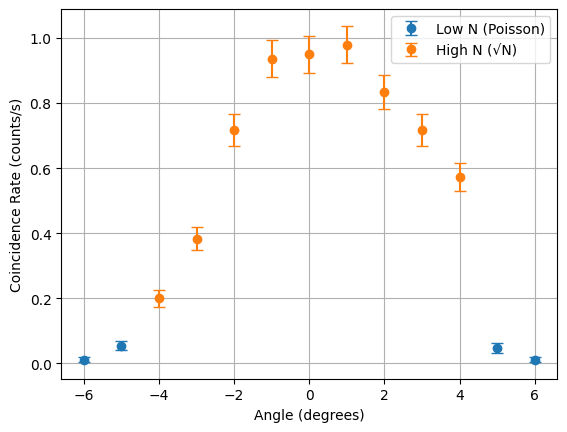

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_time = 300

low_angles, low_rates, low_err_low, low_err_high = [], [], [], []
high_angles, high_rates, high_err = [], [], []
rows = []

for angle, df in sorted(angle_data.items()):
    N = df[(df["Channel"].between(280, 350))]["Counts"].sum()
    R = N / run_time

    if N < 50 and N in poisson_68_table:
        low, high = poisson_68_table[N]
        e_low, e_high = (N - low)/run_time, (high - N)/run_time

        low_angles.append(angle)
        low_rates.append(R)
        low_err_low.append(e_low)
        low_err_high.append(e_high)

        unc_counts_low, unc_counts_high = N - low, high - N
        sigma_low, sigma_high = e_low, e_high

    else:
        e = np.sqrt(N)
        high_angles.append(angle)
        high_rates.append(R)
        high_err.append(e/run_time)

        unc_counts_low = unc_counts_high = e
        sigma_low = sigma_high = e / run_time

    rows.append({
        "Angle (deg)": angle,
        "Counts (N)": int(N),
        "Unc - (counts)": round(unc_counts_low, 3),
        "Unc + (counts)": round(unc_counts_high, 3),
        "Rate (counts/s)": round(R, 5),
        "Unc - (counts/s)": round(sigma_low, 5),
        "Unc + (counts/s)": round(sigma_high, 5)
    })

table = pd.DataFrame(rows).sort_values("Angle (deg)")
display(table)


plt.errorbar(low_angles, low_rates, yerr=[low_err_low, low_err_high],
             fmt='o', capsize=4, label="Low N (Poisson)")
plt.errorbar(high_angles, high_rates, yerr=high_err,
             fmt='o', capsize=4, label="High N (√N)")

plt.xlabel("Angle (degrees)")
plt.ylabel("Coincidence Rate (counts/s)")
plt.legend()
plt.grid(True)
plt.show()

mu = 0.493 ± 0.158 deg
Shape Chi^2 = 0.007599118463178265
Shape Chi^2 = 169.0612796997698
Shape Chi^2/dof = 14.088439974980817


/var/folders/x0/43gp1fmn237cpl3hp5mvyljw0000gp/T/ipykernel_16073/1925495305.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  data_area = np.trapz(rates, angles)
/var/folders/x0/43gp1fmn237cpl3hp5mvyljw0000gp/T/ipykernel_16073/1925495305.py:86: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  model_area = np.trapz(model_raw, angles)
/var/folders/x0/43gp1fmn237cpl3hp5mvyljw0000gp/T/ipykernel_16073/1925495305.py:108: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  model_smooth /= np.trapz(model_smooth, x)


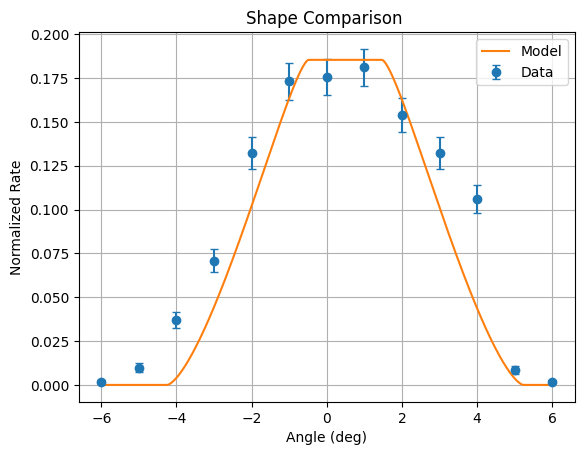

/var/folders/x0/43gp1fmn237cpl3hp5mvyljw0000gp/T/ipykernel_16073/1925495305.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  model_norm = model_at_points / np.trapz(model_at_points, angles)


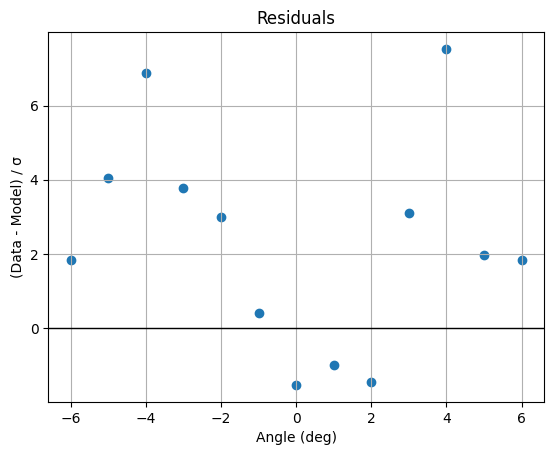

In [8]:
import numpy as np
import matplotlib.pyplot as plt

low_angles = np.array(low_angles)
low_rates = np.array(low_rates)
low_err_low = np.array(low_err_low)
low_err_high = np.array(low_err_high)

high_angles = np.array(high_angles)
high_rates = np.array(high_rates)
high_err = np.array(high_err)

angles = np.concatenate([low_angles, high_angles])
rates = np.concatenate([low_rates, high_rates])

yerr = np.concatenate([low_err_low, high_err])
yerr = np.vstack([yerr, yerr])


#center

from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


A0 = np.max(rates)
mu0 = angles[np.argmax(rates)]
sigma0 = 2.0 
popt, pcov = curve_fit(gaussian, angles, rates, p0=[A0, mu0, sigma0])

A_fit, mu_fit, sigma_fit = popt
mu_err = np.sqrt(pcov[1,1])

print(f"mu = {mu_fit:.3f} ± {mu_err:.3f} deg")




def circle_overlap(d, r1, r2):
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return np.pi * min(r1, r2)**2

    a = np.arccos((r1**2 + d**2 - r2**2) / (2 * r1 * d))
    b = np.arccos((r2**2 + d**2 - r1**2) / (2 * r2 * d))

    return (
        r1**2 * a +
        r2**2 * b -
        0.5 * np.sqrt(
            (-d + r1 + r2) *
            ( d + r1 - r2) *
            ( d - r1 + r2) *
            ( d + r1 + r2)
        )
    )

L1, r1 = 44.45, 4.445 / 2
L2, r2 = 23.1775, 1.524 / 2

Leff = (L1 * L2) / (L1 + L2)

alpha1 = np.arctan(r1 / L1)
alpha2 = np.arctan(r2 / L2)

r1_eff = Leff * np.tan(alpha1)
r2_eff = Leff * np.tan(alpha2)


def model(theta_deg, shift=0.0):
    theta = np.radians(theta_deg - shift)   # APPLY SHIFT HERE
    d = Leff * np.tan(theta)

    return np.array([
        circle_overlap(abs(di), r1_eff, r2_eff)
        for di in d
    ])


model_raw = model(angles, shift=mu_fit)

data_area = np.trapz(rates, angles)
model_area = np.trapz(model_raw, angles)

data_shape = rates / data_area
model_shape = model_raw / model_area

chi2_shape = np.sum((data_shape - model_shape)**2)

print("Shape Chi^2 =", chi2_shape)


yerr_norm = yerr[0] / data_area

chi2_shape = np.sum(((data_shape - model_shape) / yerr_norm)**2)
dof = len(angles) - 1

print("Shape Chi^2 =", chi2_shape)
print("Shape Chi^2/dof =", chi2_shape / dof)



x = np.linspace(np.min(angles), np.max(angles), 400)
model_smooth = model(x, shift=mu_fit)
model_smooth /= np.trapz(model_smooth, x)

plt.errorbar(
    angles,
    data_shape,
    yerr=yerr / data_area,
    fmt='o',
    capsize=3,
    label="Data"
)

plt.plot(x, model_smooth, label="Model")

plt.title("Shape Comparison ")
plt.xlabel("Angle (deg)")
plt.ylabel("Normalized Rate")
plt.legend()
plt.grid()

plt.show()

model_at_points = model(angles, shift=mu_fit)
model_norm = model_at_points / np.trapz(model_at_points, angles)

residuals = (data_shape - model_norm) / (yerr[0] / data_area)

plt.figure()

plt.axhline(0, color='black', linewidth=1)
plt.scatter(angles, residuals)

plt.title("Residuals")
plt.xlabel("Angle (deg)")
plt.ylabel("(Data - Model) / σ")
plt.grid()

plt.show()

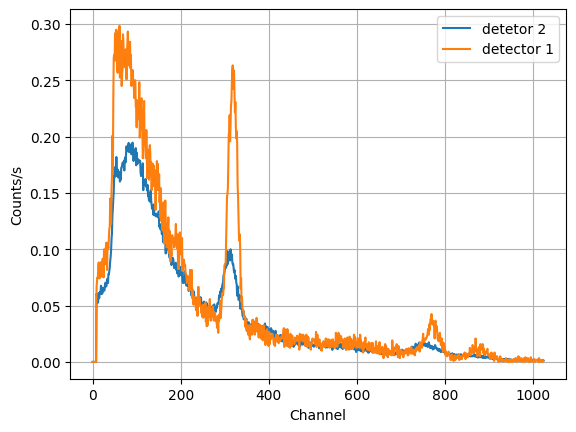

In [9]:
plt.plot(detect2['Counts']/7600, label ="detetor 2")
plt.plot(coince_off['Counts']/1200,label ="detector 1")


plt.xlabel("Channel")
plt.ylabel("Counts/s")
plt.grid()
plt.legend()
plt.show()

,Angle (deg),Counts (N),Unc - (counts),Unc + (counts),Rate (counts/s),Unc - (counts/s),Unc + (counts/s)
0,-6,0,0.00,1.84,0.00000,0.00000,0.00613
1,-5,0,0.00,1.84,0.00000,0.00000,0.00613
2,-4,0,0.00,1.84,0.00000,0.00000,0.00613
3,-3,0,0.00,1.84,0.00000,0.00000,0.00613
4,-2,0,0.00,1.84,0.00000,0.00000,0.00613
5,-1,0,0.00,1.84,0.00000,0.00000,0.00613
6,0,0,0.00,1.84,0.00000,0.00000,0.00613
7,1,0,0.00,1.84,0.00000,0.00000,0.00613
8,2,1,0.83,2.30,0.00333,0.00277,0.00767
9,3,0,0.00,1.84,0.00000,0.00000,0.00613


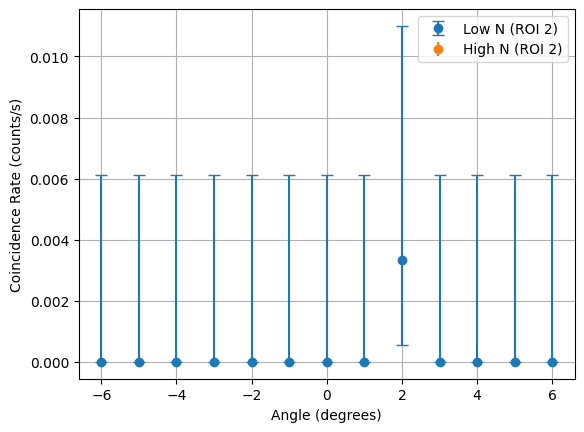

In [10]:
low_angles2, low_rates2, low_err_low2, low_err_high2 = [], [], [], []
high_angles2, high_rates2, high_err2 = [], [], []
rows2 = []

for angle, df in sorted(angle_data.items()):
    N2 = df[(df["Channel"].between(730, 820))]["Counts"].sum()
    R2 = N2 / run_time
    
    if N2 < 50 and N2 in poisson_68_table:
        low, high = poisson_68_table[N2]
        e_low, e_high = (N2 - low)/run_time, (high - N2)/run_time
        low_angles2.append(angle)
        low_rates2.append(R2)
        low_err_low2.append(e_low)
        low_err_high2.append(e_high)
        unc_counts_low, unc_counts_high = N2 - low, high - N2
        sigma_low, sigma_high = e_low, e_high
    else:
        e = np.sqrt(N2)
        high_angles2.append(angle)
        high_rates2.append(R2)
        high_err2.append(e/run_time)
        unc_counts_low = unc_counts_high = e
        sigma_low = sigma_high = e / run_time

    rows2.append({
        "Angle (deg)": angle,
        "Counts (N)": int(N2),
        "Unc - (counts)": round(unc_counts_low, 3),
        "Unc + (counts)": round(unc_counts_high, 3),
        "Rate (counts/s)": round(R2, 5),
        "Unc - (counts/s)": round(sigma_low, 5),
        "Unc + (counts/s)": round(sigma_high, 5)
    })

table2 = pd.DataFrame(rows2).sort_values("Angle (deg)")
display(table2)

plt.errorbar(low_angles2, low_rates2, yerr=[low_err_low2, low_err_high2], fmt='o', capsize=4, label="Low N (ROI 2)")
plt.errorbar(high_angles2, high_rates2, yerr=high_err2, fmt='o', capsize=4, label="High N (ROI 2)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Coincidence Rate (counts/s)")
plt.legend()
plt.grid(True)
plt.show()


In [11]:

import numpy as np

def get_roi_counts(df, low_channel=280, high_channel=350):
    roi = df[df["Channel"].between(low_channel, high_channel)]
    return roi["Counts"].sum()
def poisson_bounds(N, poisson_68_table):
    """
    Returns asymmetric (low, high) bounds for Poisson.
    Falls back to sqrt(N) if not in table.
    """
    if N in poisson_68_table:
        low, high = poisson_68_table[N]
        return low, high
    else:
        sigma = np.sqrt(N)
        return N - sigma, N + sigma


t1 = 1200
t2 = 7600

N_on = get_roi_counts(coince_on)
N_off = get_roi_counts(coince_off)
N_2 = get_roi_counts(detect2)
tau = (N_on * t2) / (N_off * N_2)
rel_err = np.sqrt(1/N_on + 1/N_off + 1/N_2)
tau_gauss_err = tau * rel_err



on_low, on_high = poisson_bounds(N_on, poisson_68_table)
off_low, off_high = poisson_bounds(N_off, poisson_68_table)
n2_low, n2_high = poisson_bounds(N_2, poisson_68_table)

tau_plus = (on_high * t2) / (off_low * n2_low)
tau_minus = (on_low * t2) / (off_high * n2_high)

tau_err_plus = tau_plus - tau
tau_err_minus = tau - tau_minus

print(f"tau (Gaussian) = {tau:.3e} ± {tau_gauss_err:.1e} s")
print(f"tau (asymmetric) = {tau:.3e} +{tau_err_plus:.1e} -{tau_err_minus:.1e} s")

tau (Gaussian) = 2.164e-05 ± 2.2e-05 s
tau (asymmetric) = 2.164e-05 +5.1e-05 -1.8e-05 s
